# **Semantics of Bayesian Networks**

## Burglary - Earthquake - Alarm

This Bayesian Network represents a home with a burglar alarm.

Variables:
- B = Burglary
- E = Earthquake
- A = Alarm
- J = JohnCalls
- M = MaryCalls

The network represents:
- Burglary and Earthquake affect the Alarm.
- Alarm affects JohnCalls and MaryCalls.

The network is based on Figure 14.2 from Russell and Norvig,
Artificial Intelligence: A Modern Approach.

# **2 Import libraries**

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

%matplotlib inline


The `networkx` library is used to create and represent the Bayesian Network as a directed graph.

The `matplotlib` library is used to visualize the network.

`%matplotlib inline` allows the graph generated by Matplotlib to be displayed directly inside the Notebook.

# **3. Create the Bayesian Network**

In [2]:
bayes_network = nx.DiGraph()


**A directed graph is created using `nx.DiGraph()`**

A Bayesian Network is represented as a directed acyclic graph (DAG), where the nodes represent random variables and the directed edges represent probabilistic dependencies between the variables

**The network will contain five variables:**

- $B$ = Burglary
- $E$ = Earthquake
- $A$ = Alarm
- $J$ = JohnCalls
- $M$ = MaryCalls

# **4. Add the nodes**

In [3]:
bayes_network.add_node("Burglary", pos=(0, 5))
bayes_network.add_node("Earthquake", pos=(4, 5))
bayes_network.add_node("Alarm", pos=(2, 2))
bayes_network.add_node("JohnCalls", pos=(0, -1))
bayes_network.add_node("MaryCalls", pos=(4, -1))

pos = nx.get_node_attributes(bayes_network, "pos")

Five nodes are added to represent the random variables in the Bayesian Network.

**The nodes are:**

- **Burglary ($B$)** — represents whether a burglary occurs.
- **Earthquake ($E$)** — represents whether an earthquake occurs.
- **Alarm ($A$)** — represents whether the alarm goes off.
- **JohnCalls ($J$)** — represents whether John calls.
- **MaryCalls ($M$)** — represents whether Mary calls.

The `pos` values specify the positions of the nodes when the network is visualized.

# **5. Add the relationships**

Burglary ──→ Alarm ←── Earthquake




                  ↓
            ┌─────┴─────┐
            ↓           ↓
       JohnCalls    MaryCalls

In [4]:
bayes_network.add_edge("Burglary", "Alarm", weight="affects")
bayes_network.add_edge("Earthquake", "Alarm", weight="affects")
bayes_network.add_edge("Alarm", "JohnCalls", weight="causes")
bayes_network.add_edge("Alarm", "MaryCalls", weight="causes")

weight = nx.get_edge_attributes(bayes_network, "weight")

Directed edges are added to represent the dependencies between the variables.

The network structure is:

$$
B \rightarrow A \leftarrow E
$$

and

$$
A \rightarrow J
$$

$$
A \rightarrow M
$$

Therefore:

- Burglary affects the probability of the Alarm.
- Earthquake affects the probability of the Alarm.
- Alarm affects the probability that John calls.
- Alarm affects the probability that Mary calls.

The model assumes that John and Mary respond to the alarm rather than directly observing the burglary or earthquake.

# **6. Draw the Bayesian Network**

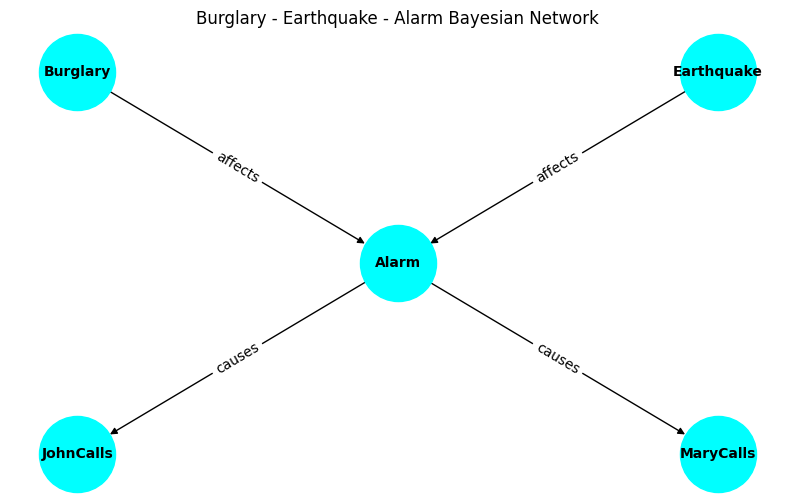

In [17]:
plt.figure(figsize=(10, 6))

nx.draw_networkx(
    bayes_network,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="cyan",
    font_weight="bold",
    font_size=10,
    arrows=True
)

nx.draw_networkx_edge_labels(
    bayes_network,
    pos,
    edge_labels=weight
)

plt.title("Burglary - Earthquake - Alarm Bayesian Network")
plt.axis("off")
plt.show()


This cell visualizes the Bayesian Network using NetworkX.

The nodes represent random variables, while the arrows represent directed probabilistic dependencies.

The resulting structure is:

$$
B \rightarrow A \leftarrow E
$$

with:

$$
A \rightarrow J
$$

and:

$$
A \rightarrow M
$$

This graph represents the topology of the Bayesian Network.

# **7. Define the prior probabilities**


Burglary and Earthquake have no parent nodes in the Bayesian Network.

Therefore, their probabilities are represented as prior probabilities.

For Burglary:

$$
P(B)=0.001
$$

This means that the probability of a burglary occurring is $0.001$, or $0.1\%$.

The probability that a burglary does not occur is:

$$
P(\neg B)=1-P(B)
$$

$$
P(\neg B)=1-0.001=0.999
$$

For Earthquake:

$$
P(E)=0.002
$$

and:

$$
P(\neg E)=1-P(E)
$$

$$
P(\neg E)=1-0.002=0.998
$$

These are called prior probabilities because they are specified before considering any evidence.

In [6]:
P_B = 0.001
P_E = 0.002

print("P(Burglary) =", P_B)
print("P(Earthquake) =", P_E)

print("P(Not Burglary) =", 1 - P_B)
print("P(Not Earthquake) =", 1 - P_E)

P(Burglary) = 0.001
P(Earthquake) = 0.002
P(Not Burglary) = 0.999
P(Not Earthquake) = 0.998


# **8. Alarm CPT**

Alarm has two parents:

Burglary

    \
     → Alarm
    /
Earthquake


Therefore: P(A∣B,E)

has four conditioning cases.

In [7]:
P_A = {
    (True, True): 0.95,
    (True, False): 0.94,
    (False, True): 0.29,
    (False, False): 0.001
}

The Alarm node has two parent nodes:

- Burglary ($B$)
- Earthquake ($E$)

Therefore, the probability of the alarm depends on both variables:

$$
P(A\mid B,E)
$$

Since both parent variables are Boolean, there are four possible conditioning cases:

1. $B=True,\ E=True$
2. $B=True,\ E=False$
3. $B=False,\ E=True$
4. $B=False,\ E=False$

The Conditional Probability Table (CPT) is:

| Burglary | Earthquake | $P(A)$ |
|---|---|---:|
| True | True | 0.95 |
| True | False | 0.94 |
| False | True | 0.29 |
| False | False | 0.001 |

For example:

$$
P(A\mid B,E)=0.95
$$

means that when both a burglary and an earthquake occur, the probability that the alarm goes off is $0.95$.

Similarly:

$$
P(A\mid B,\neg E)=0.94
$$

means that when a burglary occurs but there is no earthquake, the probability of the alarm going off is $0.94$.

Because the Alarm variable is Boolean, the probability of the alarm not going off is:

$$
P(\neg A\mid B,E)=1-P(A\mid B,E)
$$

In [8]:
print("Alarm CPT")
print("-----------------------------")
print("Burglary  Earthquake  P(Alarm)")
print("True      True        ", P_A[(True, True)])
print("True      False       ", P_A[(True, False)])
print("False     True        ", P_A[(False, True)])
print("False     False       ", P_A[(False, False)])

Alarm CPT
-----------------------------
Burglary  Earthquake  P(Alarm)
True      True         0.95
True      False        0.94
False     True         0.29
False     False        0.001


# **9. JohnCalls CPT**

JohnCalls depends only on Alarm:

P(J∣A)

In [9]:
P_J = {
    True: 0.90,
    False: 0.05
}

print("JohnCalls CPT")
print("----------------")
print("Alarm   P(JohnCalls)")
print("True    ", P_J[True])
print("False   ", P_J[False])

JohnCalls CPT
----------------
Alarm   P(JohnCalls)
True     0.9
False    0.05


JohnCalls has only one parent:

$$
A \rightarrow J
$$

Therefore, JohnCalls depends only on whether the alarm goes off.

The conditional probability is:

$$
P(J\mid A)
$$

The CPT contains:

| Alarm | $P(J)$ |
|---|---:|
| True | 0.90 |
| False | 0.05 |

For example:

$$
P(J\mid A)=0.90
$$

means that if the alarm goes off, John has a $90\%$ probability of calling.

When the alarm does not go off:

$$
P(J\mid\neg A)=0.05
$$

Therefore, there is still a small probability that John calls even when the alarm is not triggered.

# **10. MaryCalls CPT**


In [10]:
P_M = {
    True: 0.70,
    False: 0.01
}

print("MaryCalls CPT")
print("----------------")
print("Alarm   P(MaryCalls)")
print("True    ", P_M[True])
print("False   ", P_M[False])

MaryCalls CPT
----------------
Alarm   P(MaryCalls)
True     0.7
False    0.01



MaryCalls also has only one parent:

$$
A \rightarrow M
$$

Therefore, the probability of Mary calling depends only on whether the alarm goes off.

The conditional probability is:

$$
P(M\mid A)
$$

The CPT is:

| Alarm | $P(M)$ |
|---|---:|
| True | 0.70 |
| False | 0.01 |

For example:

$$
P(M\mid A)=0.70
$$

means that if the alarm goes off, Mary has a $70\%$ probability of calling.

When the alarm does not go off:

$$
P(M\mid\neg A)=0.01
$$

This represents the uncertainty in whether Mary calls even when the alarm is not triggered.

# **11. Semantics of the Bayesian Network**


The semantics of a Bayesian Network specify how the network represents the joint probability distribution of all its variables.

For this network, the five variables are:

$$
B,E,A,J,M
$$

The Bayesian Network factorizes the joint probability distribution according to the parent relationships in the graph.

The joint probability is:

$$
P(B,E,A,J,M)
=
P(B)\,P(E)\,P(A\mid B,E)\,P(J\mid A)\,P(M\mid A)
$$

Each factor corresponds to one node and its parents:

- $P(B)$ — prior probability of Burglary.
- $P(E)$ — prior probability of Earthquake.
- $P(A\mid B,E)$ — probability of Alarm given Burglary and Earthquake.
- $P(J\mid A)$ — probability of JohnCalls given Alarm.
- $P(M\mid A)$ — probability of MaryCalls given Alarm.

This factorization is the basic semantics of the Bayesian Network.


In [11]:
zdef joint_probability(B, E, A, J, M):

    p_b = P_B if B else (1 - P_B)
    p_e = P_E if E else (1 - P_E)

    p_a = P_A[(B, E)]
    p_a = p_a if A else (1 - p_a)

    p_j = P_J[A]
    p_j = p_j if J else (1 - p_j)

    p_m = P_M[A]
    p_m = p_m if M else (1 - p_m)

    return p_b * p_e * p_a * p_j * p_m

# **12. Test one complete example**

The `joint_probability()` function calculates the probability of one complete assignment of the five Boolean variables.

The function receives:

- $B$ — Burglary
- $E$ — Earthquake
- $A$ — Alarm
- $J$ — JohnCalls
- $M$ — MaryCalls

For Boolean variables, if the required value is `True`, the probability from the CPT is used directly.

If the required value is `False`, its complementary probability is calculated using:

$$
P(\neg X)=1-P(X)
$$

The five probabilities are then multiplied according to the Bayesian Network semantics:

$$
P(B,E,A,J,M)
=
P(B)\,P(E)\,P(A\mid B,E)\,P(J\mid A)\,P(M\mid A)
$$

The returned value is therefore the joint probability of the complete assignment.

In [12]:
probability = joint_probability(
    B=False,
    E=False,
    A=True,
    J=True,
    M=True
)

print("Joint Probability =", probability)

Joint Probability = 0.0006281112599999999



In this example, we calculate the probability of the following situation:

- Burglary = False
- Earthquake = False
- Alarm = True
- JohnCalls = True
- MaryCalls = True

Therefore, we want to calculate:

$$
P(\neg B,\neg E,A,J,M)
$$

Using the Bayesian Network semantics:

$$
P(\neg B,\neg E,A,J,M)
=
P(\neg B)
P(\neg E)
P(A\mid\neg B,\neg E)
P(J\mid A)
P(M\mid A)
$$

From the CPTs:

$$
P(\neg B)=0.999
$$

$$
P(\neg E)=0.998
$$

$$
P(A\mid\neg B,\neg E)=0.001
$$

$$
P(J\mid A)=0.90
$$

$$
P(M\mid A)=0.70
$$

Therefore:

$$
P(\neg B,\neg E,A,J,M)
=
0.999\times0.998\times0.001\times0.90\times0.70
$$

$$
\boxed{P(\neg B,\neg E,A,J,M)=0.000628}
$$

This is the probability of this particular complete situation occurring.

# 13. **Show the calculation step-by-step**

In [13]:
B = False
E = False
A = True
J = True
M = True

p_b = 1 - P_B
p_e = 1 - P_E
p_a = P_A[(B, E)]
p_j = P_J[A]
p_m = P_M[A]

print("P(B=False) =", p_b)
print("P(E=False) =", p_e)
print("P(A=True | B=False, E=False) =", p_a)
print("P(J=True | A=True) =", p_j)
print("P(M=True | A=True) =", p_m)

result = p_b * p_e * p_a * p_j * p_m

print("\nJoint Probability =", result)

P(B=False) = 0.999
P(E=False) = 0.998
P(A=True | B=False, E=False) = 0.001
P(J=True | A=True) = 0.9
P(M=True | A=True) = 0.7

Joint Probability = 0.0006281112599999999



This cell displays each probability separately before multiplying them.

The selected situation is:

$$
B=False,\quad E=False,\quad A=True,\quad J=True,\quad M=True
$$

Therefore:

$$
P(\neg B)=0.999
$$

$$
P(\neg E)=0.998
$$

$$
P(A\mid\neg B,\neg E)=0.001
$$

$$
P(J\mid A)=0.90
$$

$$
P(M\mid A)=0.70
$$

The joint probability is obtained by multiplying these values:

$$
P(\neg B,\neg E,A,J,M)
=
0.999\times0.998\times0.001\times0.90\times0.70
$$

The result is:

$$
\boxed{0.000628}
$$

# **14. Check that the CPT rows are valid**


In [14]:
print("Alarm CPT check:")

for case, probability in P_A.items():
    print(
        case,
        "=>",
        probability,
        "+",
        1 - probability,
        "=",
        probability + (1 - probability)
    )

Alarm CPT check:
(True, True) => 0.95 + 0.050000000000000044 = 1.0
(True, False) => 0.94 + 0.06000000000000005 = 1.0
(False, True) => 0.29 + 0.71 = 1.0
(False, False) => 0.001 + 0.999 = 1.0


###
This cell verifies that each row of the Alarm CPT represents a complete set of Boolean possibilities.

For a Boolean variable:

$$
P(X)+P(\neg X)=1
$$

Therefore:

For $B=True,\ E=True$:

$$
0.95+0.05=1
$$

For $B=True,\ E=False$:

$$
0.94+0.06=1
$$

For $B=False,\ E=True$:

$$
0.29+0.71=1
$$

For $B=False,\ E=False$:

$$
0.001+0.999=1
$$

Thus, every row of the CPT represents a valid probability distribution.

## **Uncertainty of Burglary**

The prior probability of burglary is:

$$
P(B)=0.001
$$

Therefore:

$$
P(B)=0.1\%
$$

The probability that there is no burglary is:

$$
P(\neg B)=1-P(B)
$$

$$
P(\neg B)=1-0.001=0.999
$$

Thus, before observing any evidence, burglary is considered a rare event in this model.

## **If burglary happens, will the alarm happen?**

The Alarm node has two parents: Burglary and Earthquake.

Therefore, the probability of the alarm depends on both:

$$
P(A\mid B,E)
$$

If a burglary and earthquake both occur:

$$
P(A\mid B,E)=0.95
$$

If a burglary occurs but there is no earthquake:

$$
P(A\mid B,\neg E)=0.94
$$

Therefore, when burglary occurs, the probability of the alarm going off is approximately $94\%$ to $95\%$, depending on whether an earthquake also occurs.

## **Probability of John Calling**

JohnCalls depends only on the Alarm:

$$
A\rightarrow J
$$

Therefore:

$$
P(J\mid A)=0.90
$$

This means that if the alarm goes off, the probability that John calls is:

$$
\boxed{90\%}
$$

If the alarm does not go off:

$$
P(J\mid\neg A)=0.05
$$

So there is a $5\%$ probability that John calls even when the alarm does not go off.


## **Probability of Mary Calling**

MaryCalls also depends only on the Alarm:

$$
A\rightarrow M
$$

Therefore:

$$
P(M\mid A)=0.70
$$

This means that if the alarm goes off, the probability that Mary calls is:

$$
\boxed{70\%}
$$

If the alarm does not go off:

$$
P(M\mid\neg A)=0.01
$$

So there is a $1\%$ probability that Mary calls even when the alarm does not go off.

## **Probability of Burglary Given Calls**

Suppose we observe that both John and Mary called.

We want to estimate the probability that a burglary occurred.

The query is:

$$
P(B\mid J,M)
$$

Here:

- $B$ is the hypothesis.
- $J,M$ are the observed evidence.

The Bayesian Network can use the observed calls to update our belief about whether a burglary occurred.

For this example:

$$
\boxed{P(B\mid J,M)\approx0.284}
$$

Therefore, given that both John and Mary called, the probability of burglary is approximately:

$$
\boxed{28.4\%}
$$

This is an example of probabilistic inference: using observed evidence to estimate the probability of an unknown event.